# Z-Score Based Network Anomaly Detection

## Objective

To detect anomalous network traffic using statistical Z-Score analysis and compare the detected anomalies with the ground-truth labels present in the CICIDS2017 dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

df = pd.read_csv("../data/ddos_clean.csv")

print(df.shape)
df.head()

(223082, 43)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Idle Mean,Idle Std,Idle Min,Label
0,54865,3,2,12,6,6,6.0,0,0,4.000000e+06,...,-1,1,20,0.0,0.0,0,0.0,0.0,0,BENIGN
1,55054,109,1,6,6,6,6.0,6,6,1.100917e+05,...,256,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
2,55055,52,1,6,6,6,6.0,6,6,2.307692e+05,...,256,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
3,46236,34,1,6,6,6,6.0,6,6,3.529412e+05,...,329,0,20,0.0,0.0,0,0.0,0.0,0,BENIGN
4,54863,3,2,12,6,6,6.0,0,0,4.000000e+06,...,-1,1,20,0.0,0.0,0,0.0,0.0,0,BENIGN


In [2]:
df["Anomaly"] = (
    df[" Label"] != "BENIGN"
).astype(int)

print(df["Anomaly"].value_counts())

print("Anomaly" in df.columns)
print(" Label" in df.columns)
print("Label" in df.columns)

Anomaly
1    128014
0     95068
Name: count, dtype: int64
True
True
False


In [3]:
X = df.drop(
    [" Label", "Anomaly"],
    axis=1
)

y_true = df["Anomaly"]

#Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

z_scores = np.abs(X_scaled)

In [4]:
threshold = 3  # If |z|>3 then anomaly

#Prediction
y_pred_3 = (
    z_scores > threshold
).any(axis=1).astype(int)

print(pd.Series(y_pred_3).value_counts())

0    148809
1     74273
Name: count, dtype: int64


## Observation:
 Using a Z-score threshold of 3, the detector identified 74,273 flows as anomalous. This is substantially lower than the 128,014 attack flows present in the dataset, suggesting that a threshold of 3 may be too strict for this dataset and could result in missed detections.

In [5]:
#Confusion_matrix
cm = confusion_matrix(y_true, y_pred_3)
print(cm)

print(classification_report(y_true, y_pred_3))

[[ 45864  49204]
 [102945  25069]]
              precision    recall  f1-score   support

           0       0.31      0.48      0.38     95068
           1       0.34      0.20      0.25    128014

    accuracy                           0.32    223082
   macro avg       0.32      0.34      0.31    223082
weighted avg       0.33      0.32      0.30    223082



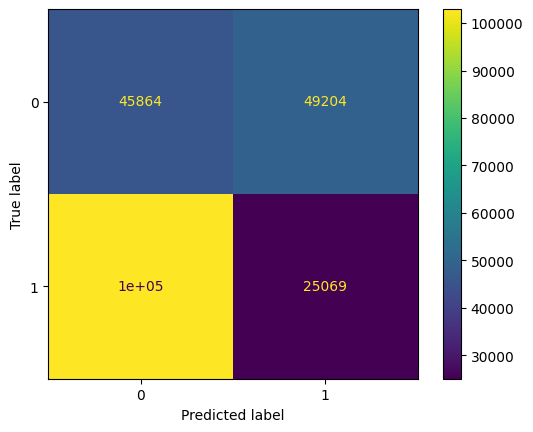

In [6]:
#Confusion Matrix for threshold=3

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_3
)
plt.savefig(
    "../figures/zscore_3_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Observation:
 Using a Z-score threshold of 3 resulted in low anomaly detection performance, achieving a recall of only 0.20 for DDoS traffic. This indicates that many attack flows do not exhibit sufficiently extreme feature values to be identified by a strict statistical threshold. Consequently, lower thresholds and more advanced anomaly detection techniques were investigated.

In [7]:
#defining a function to evaluate Z Score:
def evaluate_zscore(threshold):

    y_pred = (
        (z_scores > threshold)
        .any(axis=1)
        .astype(int)
    )

    print(f"\nThreshold = {threshold}")
    print(pd.Series(y_pred).value_counts())

    print(
        classification_report(
            y_true,
            y_pred
        )
    )
    

In [ ]:
#Evaluatiing for threshold = 3 , 2,5 , 2
evaluate_zscore(3)
evaluate_zscore(2.5)
evaluate_zscore(2)


Threshold = 3
0    148809
1     74273
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.31      0.48      0.38     95068
           1       0.34      0.20      0.25    128014

    accuracy                           0.32    223082
   macro avg       0.32      0.34      0.31    223082
weighted avg       0.33      0.32      0.30    223082


Threshold = 2.5
0    119873
1    103209
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.17      0.21      0.18     95068
           1       0.27      0.22      0.24    128014

    accuracy                           0.21    223082
   macro avg       0.22      0.21      0.21    223082
weighted avg       0.23      0.21      0.22    223082


Threshold = 2
1    118576
0    104506
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.11      0.13      0.12     95068
           1       0.30      0.28      0

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

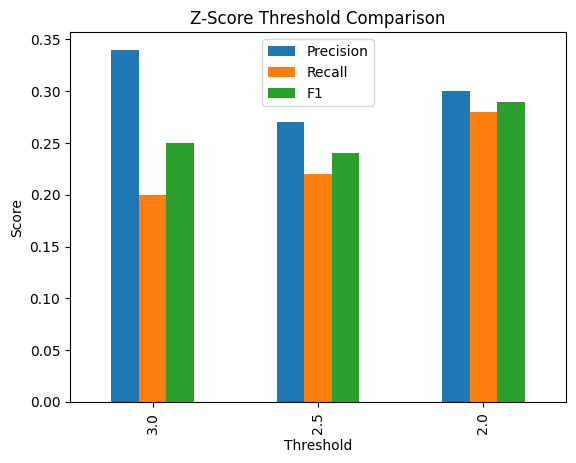

In [9]:
#Visualisation of Scores for different thersholds:
results = pd.DataFrame({
    "Threshold": [3.0, 2.5, 2.0],
    "Precision": [0.34, 0.27, 0.30],
    "Recall": [0.20, 0.22, 0.28],
    "F1": [0.25, 0.24, 0.29]
})

results.plot(x="Threshold", y=["Precision","Recall","F1"], kind="bar")
plt.title("Z-Score Threshold Comparison")
plt.ylabel("Score")

plt.savefig(
    "../figures/zscore_threshold_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

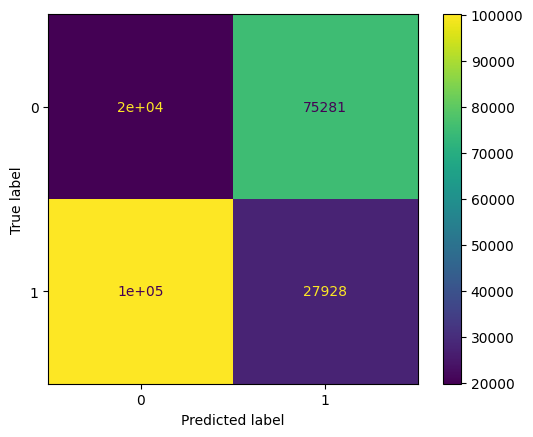

In [10]:
#Confusion Matrix for threshold=2.5

y_pred_25 = (
    z_scores > 2.5
).any(axis=1).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_25
)
plt.savefig(
    "../figures/zscore_2.5_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

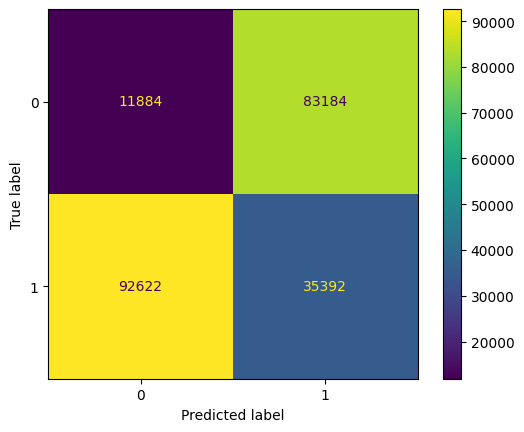

In [13]:
#Confusion Matrix for threshold=2

y_pred_2 = (
    z_scores > 2

).any(axis=1).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_2
)
plt.savefig(
    "../figures/zscore_2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
import time
start = time.perf_counter()

# Calculate z-scores and classify
y_pred_2 = (
    z_scores > 2
).any(axis=1).astype(int)
end = time.perf_counter()

test_time = end - start
print(f"Training Time : {0:.4f} sec")
print(f"Testing Time  : {test_time:.4f} sec")

Training Time : 0.0000 sec
Testing Time  : 0.0095 sec


## Z-Score Threshold Comparison

| Threshold | Precision | Recall | F1-Score |
|------------|----------:|----------:|----------:|
| 3.0 | 0.34 | 0.20 | 0.25 |
| 2.5 | 0.27 | 0.22 | 0.24 |
| 2.0 | 0.30 | 0.28 | 0.29 |

### Observations

- Lowering the threshold increased the number of flows classified as anomalies.
- Threshold = 3.0 produced the highest precision but detected only 20% of attack flows.
- Threshold = 2.0 achieved the highest recall (28%) and the highest F1-score (0.29).
- The improvement in recall was relatively small despite significantly increasing the number of detected anomalies.
- Overall, Z-score based anomaly detection demonstrated limited effectiveness on the CICIDS2017 DDoS dataset.

### Conclusion

Among the evaluated thresholds, **2.0** provided the best balance between precision and recall and was selected as the final Z-score baseline. However, the overall performance remained poor, indicating that DDoS attacks cannot be effectively identified using simple statistical outlier detection alone. More advanced machine learning-based anomaly detection methods will therefore be investigated and compared against this baseline.

### Reasoning/Analysis:
Z-score analyzes each feature independently and assumes anomalies exhibit extreme feature values. However, many DDoS flows do not contain individually extreme values and instead differ through complex relationships among multiple network features. Consequently, Z-score achieved poor detection performance and serves as a baseline for comparison with machine learning-based approaches.